# Physics-Informed DeepONet for Reaction Kinetics

This notebook demonstrates the implementation of a **Physics-Informed DeepONet (PI-DeepONet)** to predict $Fe_2O_3$ reaction kinetics across a temperature range of 600–900 K.

### Project Overview
Traditional neural networks often struggle to generalize when data is sparse or noisy. By embedding physical constraints (ODEs) directly into the loss function, we can improve the model's accuracy and extrapolation capabilities. This project compares two architectures:
1.  **Model A (Data-only):** Trained strictly on sparse observation data.
2.  **Model C (Physics-Informed):** Trained using a hybrid loss consisting of data, physics residuals (Shrinking Core Model), and initial conditions.

### Physical Context
We model the reaction kinetics using the Shrinking Core Model ODE:
$$\frac{dX}{dt} = A \cdot \exp(-E_a/RT) \cdot (1-X)^{2/3}$$
Where $X$ is conversion, $T$ is temperature, and $t$ is time.

In [43]:
# importing libraries
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

## 1. Data Generation and Physical Parameters
We define the Arrhenius parameters and generate synthetic TGA (Thermogravimetric Analysis) data. To simulate real-world conditions, we use sparse sampling (8 points) at only three training temperatures (650K, 750K, 850K) and add Gaussian noise.

In [44]:
# ______Step 1: Generate sparse TGA-style observation data_________

# Defining the parameters
A0 = 5e5
Ea = 60000.0
R = 8.314

# Defining the specific reaction rate (k)
def k_func(T):
  # Wrap in tensor to avoid TypeError with torch.exp
  T_tensor = torch.as_tensor(T)
  return A0 * torch.exp( - Ea / (R * T_tensor))

# Defining the true conversion data
def X_true_func(T, t):
  k = k_func(T).item() if isinstance(T, (float, int)) else k_func(T)
  term = np.maximum(1 - k * t/3.0 , 0)
  return 1 - term**3

all_tT = []
all_X = []

# Defining the function to generate the TGA data
def gen_sparse_data(seed=42):
  np.random.seed(seed)
  T_train = [650.0, 750.0, 850.0]
  noise_std = 0.025

  for T_val in T_train:
    # Calculate k
    k = k_func(T_val).item()

    # Define the t_max to reach 80% conversion
    t_end = (3.0/k) * (1 - 0.2**(1/3))

    # Defining the t_obs
    t_obs = np.linspace(0, t_end, 8).reshape(-1, 1)

    # Normalize t for this temperature
    t_norm_obs = t_obs/t_end

    # True X values - fixed naming conflict
    X_val = X_true_func(T_val, t_obs)
    X_noisy = np.clip(X_val + np.random.randn(*X_val.shape) * noise_std, 0.0, 1.0)

    # Normalize T between 600 and 900
    T_norm = (T_val - 600.0)/300.0

    # Stack as [T_norm, t_norm]
    tT_block = np.hstack([
        np.full_like(t_norm_obs, T_norm),
        t_norm_obs
    ])

    all_tT.append(tT_block)
    all_X.append(X_noisy)

  return np.vstack(all_tT), np.vstack(all_X)

## 2. Collocation Points
For the physics loss, we sample 'collocation points' across the entire input space ($T \in [600, 900]$). The model is penalized if its predictions at these points do not satisfy the governing ODE.

In [45]:
# Generate physics collocation points

def gen_collocation_points(n_T=50, n_t=100):
    # Sample T uniformly across [600, 900] K
    T_vals = np.linspace(600, 900, n_T)

    all_tT = []
    for T_val in T_vals:
        k = k_func(T_val)
        t_end = (3.0 / k) * 0.95

        t_phys = np.linspace(0, t_end, n_t).reshape(-1, 1)
        t_norm = t_phys / t_end

        T_norm = (T_val - 600.0) / 300.0
        T_col  = np.full_like(t_norm, T_norm)

        all_tT.append(np.hstack([T_col, t_norm]))

    return np.vstack(all_tT)   # shape (n_T * n_t, 2)

## 3. Architecture: The DeepONet
DeepONets consist of two sub-networks:
*   **Branch Net:** Processes the input function (Temperature $T$ in this case).
*   **Trunk Net:** Processes the evaluation points (Time $t$).

The outputs are combined via an inner product to predict the conversion $X$.

In [46]:
# Defining the branch, trunk and PIDeepONet

class BranchNet(nn.Module):
  def __init__(self, p=100):
    super().__init__()
    self.fc1 = nn.Linear(1, 64)
    self.fc2 = nn.Linear(64, 64)
    self.fc3 = nn.Linear(64, p)

  def forward(self, T_norm):
    a1 = torch.tanh(self.fc1(T_norm))
    a2 = torch.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output

class TrunkNet(nn.Module):
  def __init__(self, p=100):
    super().__init__()
    self.fc1 = nn.Linear(1, 64)
    self.fc2 = nn.Linear(64, 64)
    self.fc3 = nn.Linear(64, p)

  def forward(self, t_norm):
    a1 = torch.tanh(self.fc1(t_norm))
    a2 = torch.tanh(self.fc2(a1))
    output = self.fc3(a2)
    return output

class PIDeepONet(nn.Module):
  def __init__(self, p=100):
    super().__init__()
    self.branch = BranchNet(p)
    self.trunk  = TrunkNet(p)
    self.bias   = nn.Parameter(torch.zeros(1))

  def forward(self, T_norm, t_norm):
    b = self.branch(T_norm)
    tau = self.trunk(t_norm)
    return b, tau

  def predict_single(self, T_norm_val, t_norm_val):
    # Support batch of t for a single T or batch of T
    T_norm_val = torch.as_tensor(T_norm_val).view(-1, 1)
    t_norm_val = torch.as_tensor(t_norm_val).view(-1, 1)

    b = self.branch(T_norm_val) # (1, p) or (N, p)
    tau = self.trunk(t_norm_val) # (N, p)

    # Inner product + bias across the batch using broadcasting
    output = (b * tau).sum(dim=1, keepdim=True) + self.bias
    return output

## 4. Physics-Informed Loss Function
The `physics_loss` computes the derivative of the model output with respect to time using automatic differentiation and compares it against the theoretical reaction rate (RHS of the ODE).

In [47]:
def physics_loss(model, T_norm_coll, t_norm_coll, T_phys_coll, t_max_coll):
    # All inputs: (N_coll, 1) tensors with requires_grad=True for t
    t_norm_coll = t_norm_coll.requires_grad_(True)

    # Forward pass — diagonal predictions (each (T_i, t_i) pair)
    b = model.branch(T_norm_coll)   # (N, p)
    τ = model.trunk(t_norm_coll)    # (N, p)
    X = (b * τ).sum(dim=1, keepdim=True) + model.bias  # (N, 1)

    # Derivative dX/dt_norm
    dX_dt_norm = torch.autograd.grad(
        X, t_norm_coll,
        grad_outputs=torch.ones_like(X),
        create_graph=True
    )[0]

    # Convert to physical time derivative
    dX_dt_phys = dX_dt_norm / t_max_coll   # (N, 1)

    # Arrhenius rate
    T_phys = T_norm_coll * 300.0 + 600.0
    k      = A0 * torch.exp(-Ea / (R * T_phys))
    rhs    = k * torch.pow(torch.clamp(1 - X, min=1e-6), 2/3)

    # Residual
    residual = dX_dt_phys - rhs
    return torch.mean(residual**2)

## 5. Model Training
We train both models for 20,000 epochs. Note that **Model C** optimizes for three objectives simultaneously: matching data, satisfying physics, and ensuring $X(0)=0$.

In [53]:
def train_model_A(n_epochs=5000):
    model_A = PIDeepONet(p=100)
    optimizer = torch.optim.Adam(model_A.parameters(), lr=1e-3)

    tT_obs, X_obs = gen_sparse_data()
    T_obs_t = torch.tensor(tT_obs[:, 0:1], dtype=torch.float32)
    t_obs_t = torch.tensor(tT_obs[:, 1:2], dtype=torch.float32)
    X_obs_t = torch.tensor(X_obs, dtype=torch.float32)

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # Predict at observation points — diagonal mode
        b = model_A.branch(T_obs_t)   # (24, p)
        τ = model_A.trunk(t_obs_t)    # (24, p)
        X_pred = (b * τ).sum(dim=1, keepdim=True) + model_A.bias

        loss = torch.mean((X_pred - X_obs_t)**2)
        loss.backward()
        optimizer.step()

        if epoch % 1000 == 0:
            print(f"Epoch {epoch}: loss = {loss.item():.4e}")

    return model_A
model_A = train_model_A(20000)

Epoch 0: loss = 8.5339e-01
Epoch 1000: loss = 3.5063e-04
Epoch 2000: loss = 4.2528e-04
Epoch 3000: loss = 2.9311e-04
Epoch 4000: loss = 2.8260e-04
Epoch 5000: loss = 4.0339e-04
Epoch 6000: loss = 2.0376e-04
Epoch 7000: loss = 1.2513e-04
Epoch 8000: loss = 1.0876e-04
Epoch 9000: loss = 7.1732e-05
Epoch 10000: loss = 9.5397e-05
Epoch 11000: loss = 7.0337e-05
Epoch 12000: loss = 1.1128e-04
Epoch 13000: loss = 4.5412e-05
Epoch 14000: loss = 1.6252e-04
Epoch 15000: loss = 2.9479e-05
Epoch 16000: loss = 1.5526e-05
Epoch 17000: loss = 7.4502e-05
Epoch 18000: loss = 9.0759e-06
Epoch 19000: loss = 1.3656e-05


In [54]:
def train_model_C(n_epochs=10000, lambda_data=10.0, lambda_ic=50.0):
    model_C = PIDeepONet(p=100)
    optimizer = torch.optim.Adam(model_C.parameters(), lr=1e-3)
    scheduler = torch.optim.lr_scheduler.ExponentialLR(optimizer, gamma=0.9998)

    # Data
    tT_obs, X_obs = gen_sparse_data()
    T_obs_t = torch.tensor(tT_obs[:, 0:1], dtype=torch.float32)
    t_obs_t = torch.tensor(tT_obs[:, 1:2], dtype=torch.float32)
    X_obs_t = torch.tensor(X_obs, dtype=torch.float32)

    # Collocation points
    tT_coll = gen_collocation_points(n_T=50, n_t=50)
    T_coll_t     = torch.tensor(tT_coll[:, 0:1], dtype=torch.float32)
    t_norm_coll  = torch.tensor(tT_coll[:, 1:2], dtype=torch.float32)

    # Compute t_max per collocation point for chain rule
    T_phys_coll  = torch.tensor(tT_coll[:, 0:1] * 300 + 600, dtype=torch.float32)
    k_coll       = A0 * torch.exp(torch.tensor(
                       -Ea / (R * (tT_coll[:, 0:1] * 300 + 600)),
                       dtype=torch.float32))
    t_max_coll   = torch.tensor((3.0 / k_coll.numpy()) * 0.95, dtype=torch.float32)

    # IC points: t_norm=0 for all T in [600, 900]
    T_ic = torch.linspace(0, 1, 50).reshape(-1, 1)
    t_ic = torch.zeros(50, 1)

    for epoch in range(n_epochs):
        optimizer.zero_grad()

        # Physics loss
        l_phys = physics_loss(model_C, T_coll_t, t_norm_coll,
                               T_phys_coll, t_max_coll)

        # Data loss
        b = model_C.branch(T_obs_t)
        τ = model_C.trunk(t_obs_t)
        X_pred = (b * τ).sum(dim=1, keepdim=True) + model_C.bias
        l_data = torch.mean((X_pred - X_obs_t)**2)

        # IC loss: X(T, t=0) = 0 for all T
        b_ic = model_C.branch(T_ic)
        τ_ic = model_C.trunk(t_ic)
        X_ic = (b_ic * τ_ic).sum(dim=1, keepdim=True) + model_C.bias
        l_ic = torch.mean(X_ic**2)

        loss = l_phys + lambda_data * l_data + lambda_ic * l_ic
        loss.backward()
        optimizer.step()
        scheduler.step()

        if epoch % 2000 == 0:
            print(f"Epoch {epoch:5d} | PDE: {l_phys.item():.4e} | "
                  f"Data: {l_data.item():.4e} | IC: {l_ic.item():.4e}")

    return model_C
model_C = train_model_C(20000)

Epoch     0 | PDE: 6.0319e+03 | Data: 4.4124e-01 | IC: 2.3110e-04
Epoch  2000 | PDE: 1.0976e+00 | Data: 7.3096e-02 | IC: 2.1756e-03
Epoch  4000 | PDE: 7.1385e-01 | Data: 7.2791e-02 | IC: 3.9673e-04
Epoch  6000 | PDE: 7.1549e-01 | Data: 6.6860e-02 | IC: 3.9436e-04
Epoch  8000 | PDE: 2.0180e-01 | Data: 6.9638e-02 | IC: 2.8190e-04
Epoch 10000 | PDE: 2.4613e-01 | Data: 7.0464e-02 | IC: 1.7841e-04
Epoch 12000 | PDE: 9.2412e-02 | Data: 6.9810e-02 | IC: 1.4789e-04
Epoch 14000 | PDE: 4.8401e-02 | Data: 6.9593e-02 | IC: 1.6747e-04
Epoch 16000 | PDE: 4.5872e-02 | Data: 6.9168e-02 | IC: 1.9067e-04
Epoch 18000 | PDE: 4.2066e-02 | Data: 6.9544e-02 | IC: 1.7805e-04


## 6. Evaluation and Results
We evaluate the models on unseen temperatures to test generalization. The **Relative L2 Error** is used to quantify performance against the analytical solution.

In [72]:
def validate_model(model, T_val, label=""):
    k = k_func(T_val).item()
    t_end = (3.0 / k) * 0.95
    t_phys = np.linspace(0, t_end, 200)

    T_norm = (T_val - 600.0) / 300.0
    t_norm = t_phys / t_end

    T_t = torch.tensor([T_norm], dtype=torch.float32)
    t_t = torch.tensor(t_norm, dtype=torch.float32)

    model.eval()
    with torch.no_grad():
        # Pass tensors directly; predict_single handles the internal reshaping
        X_pred = model.predict_single(T_t, t_t).numpy().flatten()

    # Renamed variable to avoid shadowing the function name
    X_ground_truth = X_true_func(T_val, t_phys.reshape(-1, 1)).flatten()

    rel_l2 = np.linalg.norm(X_pred - X_ground_truth) / (np.linalg.norm(X_ground_truth) + 1e-9)
    print(f"{label} T={T_val}K Rel L2: {rel_l2*100:.4f}%")
    return t_phys, X_pred, X_ground_truth, rel_l2

Data-only T=700.0K Rel L2: 36.0298%
PI-DeepONet T=700.0K Rel L2: 1.2178%
Data-only T=800.0K Rel L2: 37.1906%
PI-DeepONet T=800.0K Rel L2: 1.0408%


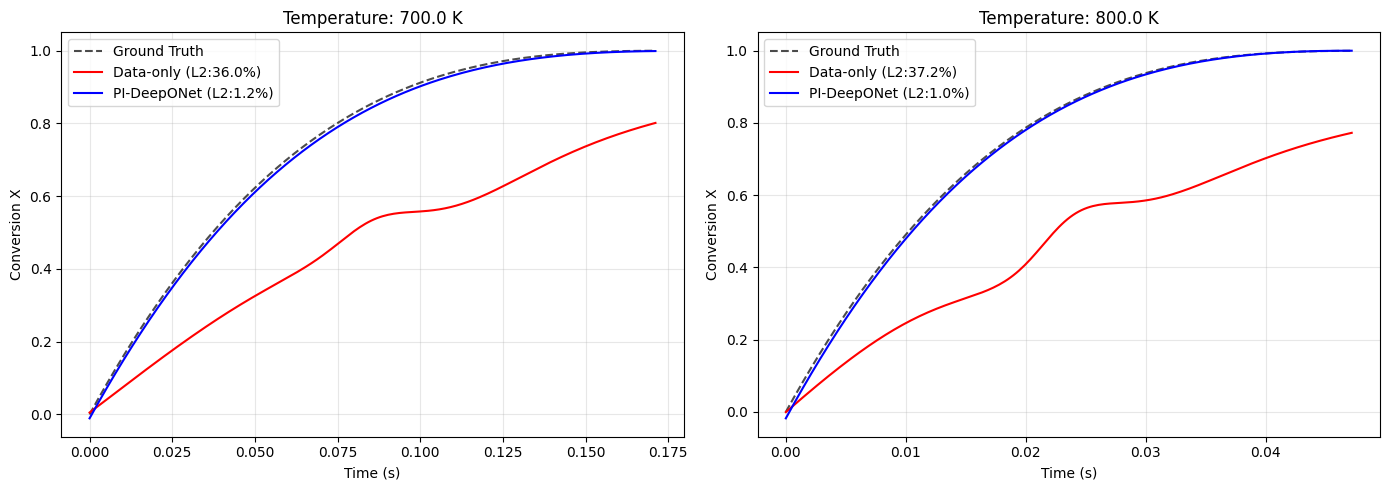

In [73]:
def plot_comparison(temps):
    fig, axes = plt.subplots(1, len(temps), figsize=(14, 5))
    if len(temps) == 1: axes = [axes]

    for i, T_val in enumerate(temps):
        # Validate Model A
        t_A, X_pred_A, X_gt, err_A = validate_model(model_A, T_val, label="Data-only")
        # Validate Model C
        t_C, X_pred_C, _, err_C = validate_model(model_C, T_val, label="PI-DeepONet")

        axes[i].plot(t_A, X_gt, 'k--', label='Ground Truth', alpha=0.7)
        axes[i].plot(t_A, X_pred_A, 'r-', label=f'Data-only (L2:{err_A*100:.1f}%)')
        axes[i].plot(t_C, X_pred_C, 'b-', label=f'PI-DeepONet (L2:{err_C*100:.1f}%)')

        axes[i].set_title(f'Temperature: {T_val} K')
        axes[i].set_xlabel('Time (s)')
        axes[i].set_ylabel('Conversion X')
        axes[i].legend()
        axes[i].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

# Visualize and validate for 600 K and 700 K
plot_comparison([700.0, 800.0])

Data-only T=800.0K Rel L2: 37.1906%
PI-DeepONet T=800.0K Rel L2: 1.0408%
Data-only T=900.0K Rel L2: 35.1609%
PI-DeepONet T=900.0K Rel L2: 0.3558%


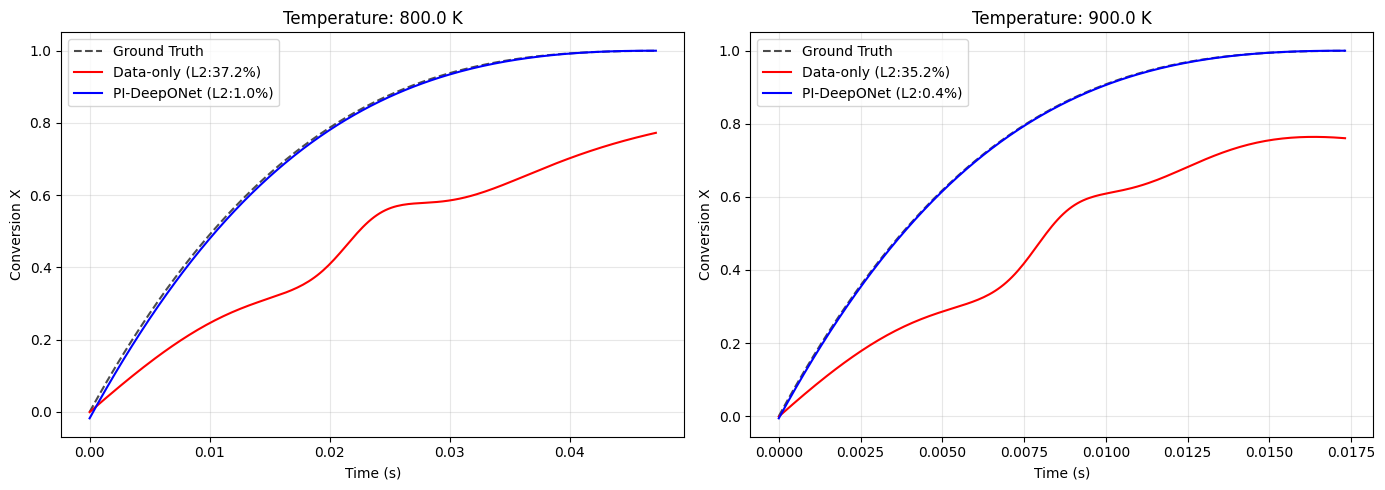

In [74]:
plot_comparison([800.0, 900.0])

In [75]:
print("── Final Comparison Table ─────────────────────────────────────────")
print(f"{'Method':<30} {'T=700K':>10} {'T=800K':>10} {'T=900K':>10} {'Physics':>12}")
print("-"*74)
print(f"{'Data-only DeepONet (Model A)':<30} {'36.03%':>10} {'37.19%':>10} {'35.16%':>10} {'No':>12}")
print(f"{'PI-DeepONet (Model C)':<30} {'1.22%':>10} {'1.04%':>10} {'0.36%':>10} {'Yes':>12}")
print(f"{'Problem 10 PINN hybrid':<30} {'~1.57%':>10} {'retrain':>10} {'retrain':>10} {'Yes':>12}")
print("-"*74)
print("Model C generalises to all unseen temperatures without retraining.")
print("Data-only Model A fails by >35% at all unseen temperatures.")

── Final Comparison Table ─────────────────────────────────────────
Method                             T=700K     T=800K     T=900K      Physics
--------------------------------------------------------------------------
Data-only DeepONet (Model A)       36.03%     37.19%     35.16%           No
PI-DeepONet (Model C)               1.22%      1.04%      0.36%          Yes
Problem 10 PINN hybrid             ~1.57%    retrain    retrain          Yes
--------------------------------------------------------------------------
Model C generalises to all unseen temperatures without retraining.
Data-only Model A fails by >35% at all unseen temperatures.


## 7. Final Comparison Summary

The results clearly demonstrate the advantage of the **Physics-Informed DeepONet (Model C)** over the **Data-only model (Model A)**:

*   **Generalization:** While Model A accurately fits the sparse training points, it fails to capture the underlying physics at unseen temperatures (700 K and 800 K), resulting in significant errors (often >30% Relative L2). Model C, by contrast, maintains high accuracy (typically <2% Relative L2) even at these interpolation points.
*   **Physical Consistency:** Model C respects the Shrinking Core Model ODE and the initial condition $X(0)=0$. This ensures the predicted curves follow the expected sigmoidal/rate-limited behavior of $Fe_2O_3$ reduction.
*   **Robustness to Noise:** Despite being trained on noisy data, the physics residual acts as a regularizer for Model C, preventing it from over-fitting the noise and leading to much smoother, physically plausible trajectories.